
## Self-Supervised Super-Resolution DIP (Phantom + Fourier model)

In [ ]:
# ===============================================================
# 1. Imports and utilities
# ===============================================================
import jax, jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import optax
from misc_nnx import downsample_sinc_image, exponential_kspace_weight
from misc_nnx import charbonnier_loss, weighted_complex_mse

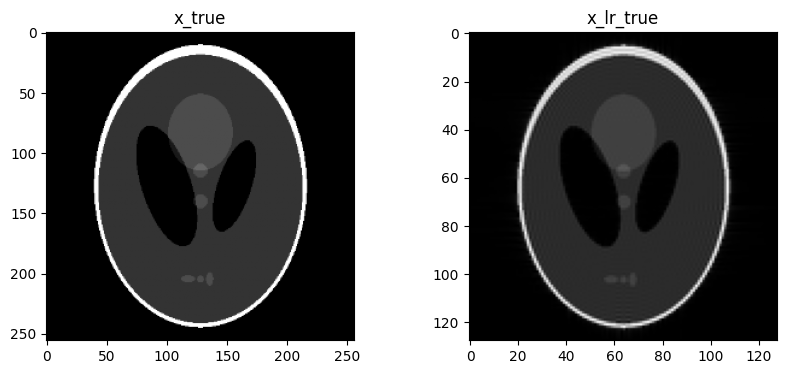

In [2]:
# ===============================================================
# 2. Phantom and Fourier model
# ===============================================================
N = 256
phantom = shepp_logan_phantom()
x_true = resize(phantom, (N, N), anti_aliasing=True)

# Super-resolution factor
s = 2
N_LR = N // s

# Ideal LR data (bandlimited + decimated)
x_lr_true, k_lr_true = downsample_sinc_image(x_true, s)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(x_true, cmap='gray')
plt.title("x_true")

plt.subplot(1,2,2)
plt.imshow(x_lr_true, cmap='gray')
plt.title("x_lr_true")
plt.show()


In [102]:
# ===============================================================
# 3. Shared decoder network
# ===============================================================
# from misc_nnx import DecoderNNX  # the one we fixed before
from misc_nnx import UNetDIP

key = jax.random.key(0)
model = UNetDIP(in_channels=1, out_channels=1, features=(32,64,128,256), rngs=nnx.Rngs(key))

In [103]:
# ===============================================================
# 4. Noise inputs (fixed)
# ===============================================================
key = jax.random.key(0)
z_hr = jax.random.normal(key, (256, 256))
z_lr, kz_lr = downsample_sinc_image(z_hr, s=2)


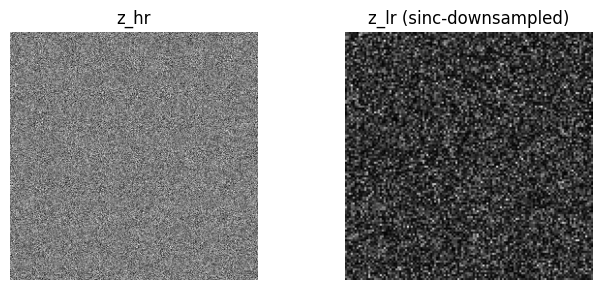

In [104]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Display both with shared scale
im1 = axes[0].imshow(z_hr, cmap='gray')
axes[0].set_title('z_hr')
axes[0].axis('off')

im2 = axes[1].imshow(z_lr, cmap='gray')
axes[1].set_title('z_lr (sinc-downsampled)')
axes[1].axis('off')

# Shared colorbar — properly placed to the right
# cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8, pad=0.05)
# cbar.set_label('Intensity', rotation=270, labelpad=12)

plt.tight_layout()
plt.show()


In [ ]:
# ===============================================================
# 5. Loss functions
# ===============================================================
# Precompute once (outside loss)
from misc_nnx import fft2c

W_exp = exponential_kspace_weight(N_LR, c=0.8)

def loss_fn(model, beta=0.001):
    # HR and LR predictions
    I_hr_pred  = model(z_hr, training=True)[0, :, :, 0]
    # Forward model (for now is just fourier transform) 
    I_lr_pred, k_lr_pred  = downsample_sinc_image(I_hr_pred, s=2)

    I_lr2_pred  = model(z_lr, training=True)[0, :, :, 0]
    k_lr2_pred  = fft2c(I_lr2_pred)

    # unsupervised
    L_img1 = charbonnier_loss(I_lr_pred, x_lr_true)
    L_data1  = weighted_complex_mse(k_lr_pred, k_lr_true, W_exp)
    L_US = (L_img1 + L_data1)

    # supervised
    L_img2 = charbonnier_loss(I_lr2_pred, x_lr_true)
    L_data2  = weighted_complex_mse(k_lr2_pred, k_lr_true, W_exp)
    L_SS = beta * (L_img2 + L_data2)

    return L_SS + L_US


In [107]:
# ===============================================================
# 6. Optimizer
# ===============================================================
optimizer = nnx.Optimizer(
    model=model,
    tx=optax.adam(1e-3),
    wrt=nnx.Param
)

z_hr = z_hr[None, : , :, None]
z_lr = z_lr[None, : , :, None]

Step     0, Loss: 6.7360e-01


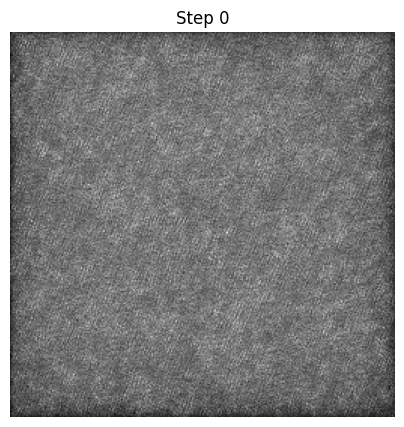

Step    10, Loss: 4.7487e-01
Step    20, Loss: 4.6312e-01
Step    30, Loss: 4.6434e-01
Step    40, Loss: 4.6116e-01
Step    50, Loss: 4.5956e-01
Step    60, Loss: 7.4414e-01
Step    70, Loss: 4.6062e-01
Step    80, Loss: 4.5967e-01
Step    90, Loss: 4.5813e-01
Step   100, Loss: 4.3827e-01
Step   110, Loss: 4.5640e-01
Step   120, Loss: 4.2447e-01
Step   130, Loss: 3.8435e-01
Step   140, Loss: 3.6300e-01
Step   150, Loss: 3.5034e-01
Step   160, Loss: 3.1337e-01
Step   170, Loss: 2.9236e-01
Step   180, Loss: 2.8125e-01
Step   190, Loss: 3.2160e-01
Step   200, Loss: 3.1281e-01
Step   210, Loss: 2.9544e-01
Step   220, Loss: 2.8097e-01
Step   230, Loss: 2.7527e-01
Step   240, Loss: 2.7096e-01
Step   250, Loss: 2.6861e-01


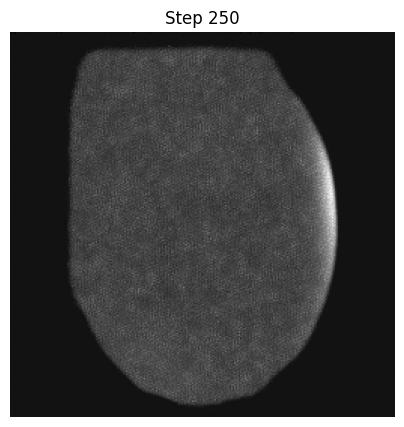

Step   260, Loss: 2.5981e-01
Step   270, Loss: 2.4040e-01
Step   280, Loss: 2.7927e-01
Step   290, Loss: 2.2646e-01
Step   300, Loss: 2.1127e-01
Step   310, Loss: 1.6219e-01
Step   320, Loss: 1.5031e-01
Step   330, Loss: 1.0854e-01
Step   340, Loss: 1.6615e-01
Step   350, Loss: 9.9617e-02
Step   360, Loss: 6.8416e-02
Step   370, Loss: 5.4093e-02
Step   380, Loss: 5.5722e-02
Step   390, Loss: 5.3787e-02
Step   400, Loss: 4.8797e-02
Step   410, Loss: 4.8867e-02
Step   420, Loss: 5.8215e-02
Step   430, Loss: 4.0276e-02
Step   440, Loss: 3.5264e-02
Step   450, Loss: 3.7470e-02
Step   460, Loss: 3.2815e-02
Step   470, Loss: 3.1111e-02
Step   480, Loss: 3.4877e-02
Step   490, Loss: 2.8671e-02
Step   500, Loss: 2.7144e-02


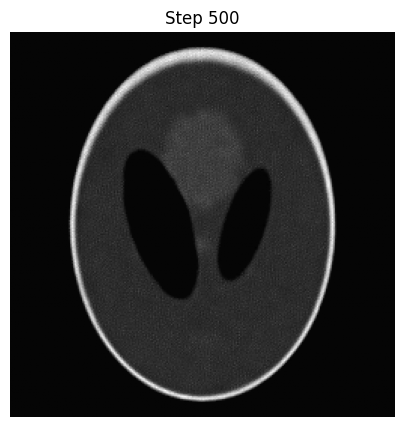

Step   510, Loss: 2.7262e-02
Step   520, Loss: 3.4661e-02
Step   530, Loss: 3.3765e-02
Step   540, Loss: 2.4806e-02
Step   550, Loss: 2.6849e-02
Step   560, Loss: 2.5391e-02
Step   570, Loss: 2.7613e-02
Step   580, Loss: 2.6049e-02
Step   590, Loss: 2.7080e-02
Step   600, Loss: 2.0891e-02
Step   610, Loss: 2.2444e-02
Step   620, Loss: 2.7573e-02
Step   630, Loss: 2.6660e-02
Step   640, Loss: 2.1668e-02
Step   650, Loss: 2.2955e-02
Step   660, Loss: 2.8583e-02
Step   670, Loss: 2.0174e-02
Step   680, Loss: 2.3019e-02
Step   690, Loss: 2.1840e-02
Step   700, Loss: 2.2716e-02
Step   710, Loss: 1.9629e-02
Step   720, Loss: 1.9288e-02
Step   730, Loss: 2.2182e-02
Step   740, Loss: 2.1981e-02
Step   750, Loss: 2.0438e-02


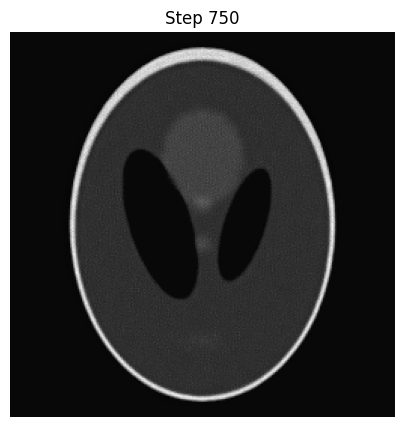

Step   760, Loss: 2.0035e-02
Step   770, Loss: 2.0365e-02
Step   780, Loss: 1.6949e-02
Step   790, Loss: 1.9161e-02
Step   800, Loss: 1.9286e-02
Step   810, Loss: 2.0386e-02
Step   820, Loss: 1.8445e-02
Step   830, Loss: 1.5138e-02
Step   840, Loss: 2.3100e-02
Step   850, Loss: 1.7008e-02
Step   860, Loss: 1.7148e-02
Step   870, Loss: 1.9676e-02
Step   880, Loss: 1.5268e-02
Step   890, Loss: 1.9332e-02
Step   900, Loss: 1.4063e-02
Step   910, Loss: 2.8489e-02
Step   920, Loss: 1.5968e-02
Step   930, Loss: 1.6441e-02
Step   940, Loss: 1.9467e-02
Step   950, Loss: 1.5795e-02
Step   960, Loss: 1.3936e-02
Step   970, Loss: 1.2708e-02
Step   980, Loss: 1.6863e-02
Step   990, Loss: 1.6097e-02
Step  1000, Loss: 1.5203e-02


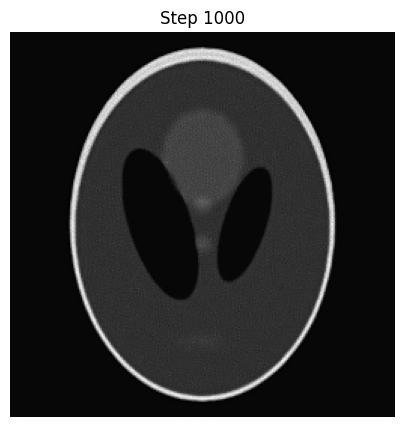

Step  1010, Loss: 1.7527e-02
Step  1020, Loss: 1.9947e-02
Step  1030, Loss: 1.4568e-02
Step  1040, Loss: 1.3776e-02
Step  1050, Loss: 1.4981e-02
Step  1060, Loss: 1.5417e-02
Step  1070, Loss: 1.5233e-02
Step  1080, Loss: 1.7148e-02
Step  1090, Loss: 1.2730e-02
Step  1100, Loss: 1.4708e-02
Step  1110, Loss: 1.5934e-02
Step  1120, Loss: 1.3810e-02
Step  1130, Loss: 1.5935e-02
Step  1140, Loss: 1.4201e-02
Step  1150, Loss: 1.5086e-02
Step  1160, Loss: 1.2668e-02
Step  1170, Loss: 1.2352e-02
Step  1180, Loss: 1.5757e-02
Step  1190, Loss: 1.3013e-02
Step  1200, Loss: 1.2688e-02
Step  1210, Loss: 1.2638e-02
Step  1220, Loss: 1.3566e-02
Step  1230, Loss: 1.4941e-02
Step  1240, Loss: 1.2226e-02
Step  1250, Loss: 1.3429e-02


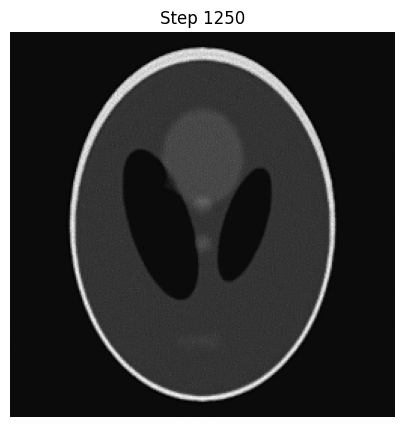

Step  1260, Loss: 1.1960e-02
Step  1270, Loss: 1.3041e-02
Step  1280, Loss: 1.5219e-02
Step  1290, Loss: 1.3293e-02
Step  1300, Loss: 1.2737e-02
Step  1310, Loss: 1.4360e-02
Step  1320, Loss: 1.3815e-02
Step  1330, Loss: 1.1779e-02
Step  1340, Loss: 1.3613e-02
Step  1350, Loss: 1.5287e-02
Step  1360, Loss: 1.2988e-02
Step  1370, Loss: 1.3286e-02
Step  1380, Loss: 1.2882e-02
Step  1390, Loss: 1.1380e-02
Step  1400, Loss: 1.2146e-02
Step  1410, Loss: 1.2661e-02
Step  1420, Loss: 1.2595e-02
Step  1430, Loss: 1.2997e-02
Step  1440, Loss: 1.0922e-02
Step  1450, Loss: 1.3661e-02
Step  1460, Loss: 1.2367e-02
Step  1470, Loss: 1.3933e-02
Step  1480, Loss: 1.0843e-02
Step  1490, Loss: 1.3109e-02
Step  1500, Loss: 1.0428e-02


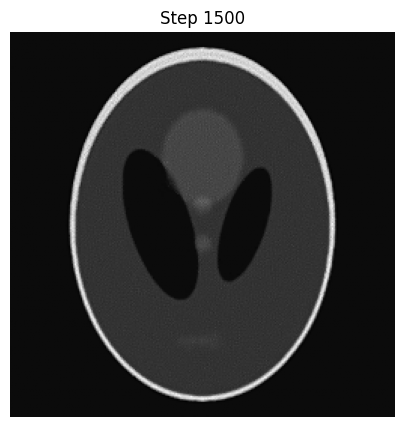

Step  1510, Loss: 1.4362e-02
Step  1520, Loss: 1.3975e-02
Step  1530, Loss: 1.0589e-02
Step  1540, Loss: 1.1353e-02
Step  1550, Loss: 1.2689e-02
Step  1560, Loss: 1.2112e-02
Step  1570, Loss: 1.1515e-02
Step  1580, Loss: 1.3922e-02
Step  1590, Loss: 1.0581e-02
Step  1600, Loss: 1.0893e-02
Step  1610, Loss: 1.0514e-02
Step  1620, Loss: 1.4608e-02
Step  1630, Loss: 1.3268e-02
Step  1640, Loss: 1.2545e-02
Step  1650, Loss: 1.1078e-02
Step  1660, Loss: 1.0981e-02
Step  1670, Loss: 1.3009e-02
Step  1680, Loss: 1.1637e-02
Step  1690, Loss: 1.2627e-02
Step  1700, Loss: 1.0844e-02
Step  1710, Loss: 1.3431e-02
Step  1720, Loss: 1.0017e-02
Step  1730, Loss: 1.1084e-02
Step  1740, Loss: 1.0184e-02
Step  1750, Loss: 1.0545e-02


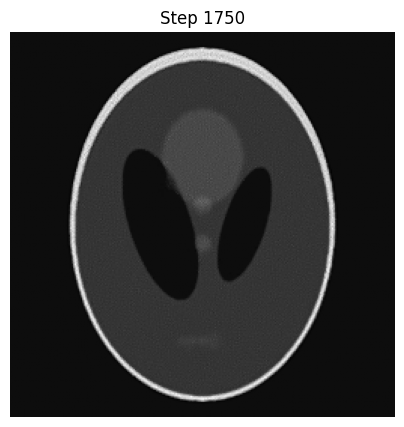

Step  1760, Loss: 1.1396e-02
Step  1770, Loss: 1.0875e-02
Step  1780, Loss: 1.0018e-02
Step  1790, Loss: 1.1251e-02
Step  1800, Loss: 1.0582e-02
Step  1810, Loss: 1.1450e-02
Step  1820, Loss: 1.0063e-02
Step  1830, Loss: 1.2946e-02
Step  1840, Loss: 1.2145e-02
Step  1850, Loss: 9.6622e-03
Step  1860, Loss: 1.0691e-02
Step  1870, Loss: 1.0573e-02
Step  1880, Loss: 1.3458e-02
Step  1890, Loss: 9.9086e-03
Step  1900, Loss: 1.2035e-02
Step  1910, Loss: 1.1883e-02
Step  1920, Loss: 1.0868e-02
Step  1930, Loss: 1.1349e-02
Step  1940, Loss: 9.3287e-03
Step  1950, Loss: 9.5768e-03
Step  1960, Loss: 9.1198e-03
Step  1970, Loss: 9.8683e-03
Step  1980, Loss: 1.1232e-02
Step  1990, Loss: 1.1408e-02
Step  2000, Loss: 9.5381e-03


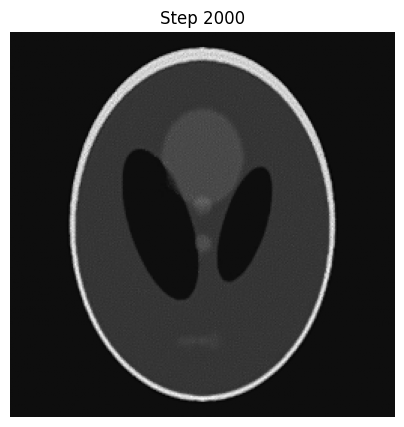

Step  2010, Loss: 1.0234e-02
Step  2020, Loss: 1.3123e-02
Step  2030, Loss: 9.0929e-03
Step  2040, Loss: 1.1076e-02
Step  2050, Loss: 1.1598e-02
Step  2060, Loss: 1.1863e-02
Step  2070, Loss: 1.0374e-02
Step  2080, Loss: 1.0126e-02
Step  2090, Loss: 1.0754e-02
Step  2100, Loss: 9.2279e-03
Step  2110, Loss: 9.1186e-03
Step  2120, Loss: 1.1887e-02
Step  2130, Loss: 9.2871e-03
Step  2140, Loss: 9.1108e-03
Step  2150, Loss: 1.0077e-02
Step  2160, Loss: 1.0718e-02
Step  2170, Loss: 1.0794e-02
Step  2180, Loss: 9.1872e-03
Step  2190, Loss: 9.2993e-03
Step  2200, Loss: 9.7170e-03
Step  2210, Loss: 1.0072e-02
Step  2220, Loss: 9.9214e-03
Step  2230, Loss: 1.1125e-02
Step  2240, Loss: 1.0291e-02
Step  2250, Loss: 9.7087e-03


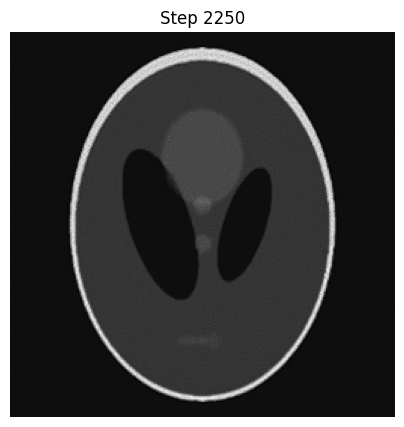

Step  2260, Loss: 9.7051e-03
Step  2270, Loss: 1.0202e-02
Step  2280, Loss: 1.0552e-02
Step  2290, Loss: 1.0652e-02
Step  2300, Loss: 1.0604e-02
Step  2310, Loss: 9.2277e-03
Step  2320, Loss: 9.0144e-03
Step  2330, Loss: 8.9216e-03
Step  2340, Loss: 7.8215e-03
Step  2350, Loss: 8.7740e-03
Step  2360, Loss: 9.0955e-03
Step  2370, Loss: 9.0005e-03
Step  2380, Loss: 8.3365e-03
Step  2390, Loss: 9.5251e-03
Step  2400, Loss: 8.9366e-03
Step  2410, Loss: 9.2820e-03
Step  2420, Loss: 9.4972e-03
Step  2430, Loss: 1.1492e-02
Step  2440, Loss: 9.2351e-03
Step  2450, Loss: 8.7532e-03
Step  2460, Loss: 9.3933e-03
Step  2470, Loss: 1.0120e-02
Step  2480, Loss: 9.1348e-03
Step  2490, Loss: 9.3032e-03
Step  2500, Loss: 8.6571e-03


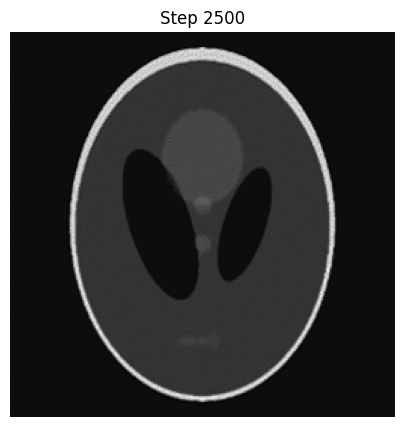

Step  2510, Loss: 8.0887e-03
Step  2520, Loss: 1.0392e-02
Step  2530, Loss: 8.1050e-03
Step  2540, Loss: 8.0718e-03
Step  2550, Loss: 7.3739e-03
Step  2560, Loss: 7.7299e-03
Step  2570, Loss: 1.0175e-02
Step  2580, Loss: 8.1410e-03
Step  2590, Loss: 8.3433e-03
Step  2600, Loss: 8.1540e-03
Step  2610, Loss: 8.5395e-03
Step  2620, Loss: 9.5208e-03
Step  2630, Loss: 8.7154e-03
Step  2640, Loss: 9.1898e-03
Step  2650, Loss: 9.2424e-03
Step  2660, Loss: 7.7523e-03
Step  2670, Loss: 8.1911e-03
Step  2680, Loss: 7.8546e-03
Step  2690, Loss: 7.1632e-03
Step  2700, Loss: 9.8319e-03
Step  2710, Loss: 7.6907e-03
Step  2720, Loss: 7.7666e-03
Step  2730, Loss: 8.7431e-03
Step  2740, Loss: 7.0579e-03
Step  2750, Loss: 6.9134e-03


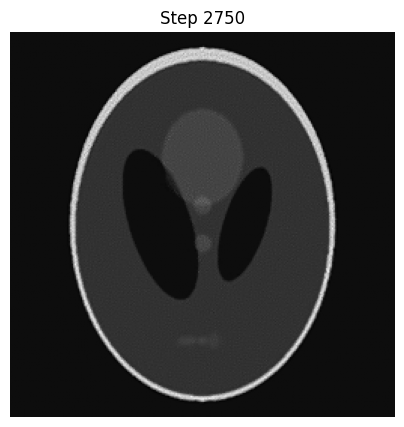

Step  2760, Loss: 9.1161e-03
Step  2770, Loss: 7.7514e-03
Step  2780, Loss: 7.3688e-03
Step  2790, Loss: 8.7594e-03
Step  2800, Loss: 7.2130e-03
Step  2810, Loss: 6.4647e-03
Step  2820, Loss: 8.5967e-03
Step  2830, Loss: 7.5132e-03
Step  2840, Loss: 8.7750e-03
Step  2850, Loss: 8.9296e-03
Step  2860, Loss: 7.9960e-03
Step  2870, Loss: 7.1778e-03
Step  2880, Loss: 7.7918e-03
Step  2890, Loss: 8.0090e-03
Step  2900, Loss: 6.5464e-03
Step  2910, Loss: 7.1777e-03
Step  2920, Loss: 1.0021e-02
Step  2930, Loss: 8.6187e-03
Step  2940, Loss: 7.6942e-03
Step  2950, Loss: 8.0620e-03
Step  2960, Loss: 7.8594e-03
Step  2970, Loss: 9.1092e-03
Step  2980, Loss: 6.8466e-03
Step  2990, Loss: 7.2520e-03
Step  3000, Loss: 7.6099e-03


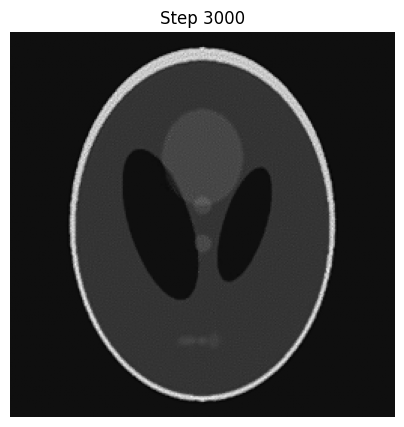

Step  3010, Loss: 8.4848e-03
Step  3020, Loss: 6.6788e-03
Step  3030, Loss: 6.1265e-03
Step  3040, Loss: 8.1750e-03
Step  3050, Loss: 6.5140e-03
Step  3060, Loss: 6.8711e-03
Step  3070, Loss: 9.0662e-03
Step  3080, Loss: 7.3625e-03
Step  3090, Loss: 8.2894e-03
Step  3100, Loss: 8.0279e-03
Step  3110, Loss: 7.1646e-03
Step  3120, Loss: 7.9125e-03
Step  3130, Loss: 6.3707e-03
Step  3140, Loss: 9.2730e-03
Step  3150, Loss: 8.8740e-03
Step  3160, Loss: 7.2662e-03
Step  3170, Loss: 1.3047e-02
Step  3180, Loss: 1.0446e-02
Step  3190, Loss: 9.3141e-03
Step  3200, Loss: 6.9111e-03
Step  3210, Loss: 7.0850e-03
Step  3220, Loss: 7.8356e-03
Step  3230, Loss: 7.6111e-03
Step  3240, Loss: 8.6021e-03
Step  3250, Loss: 6.0021e-03


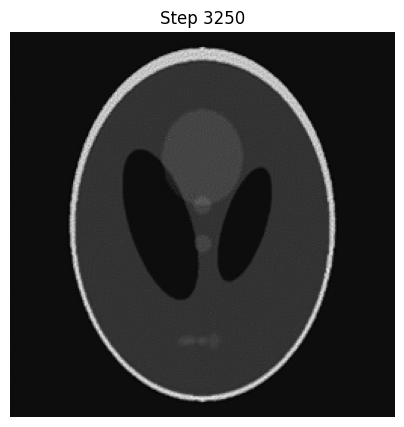

Step  3260, Loss: 8.7576e-03
Step  3270, Loss: 6.8171e-03
Step  3280, Loss: 7.3796e-03
Step  3290, Loss: 7.2826e-03
Step  3300, Loss: 7.8806e-03
Step  3310, Loss: 7.0551e-03
Step  3320, Loss: 7.0243e-03
Step  3330, Loss: 7.1764e-03
Step  3340, Loss: 6.5143e-03
Step  3350, Loss: 6.8550e-03
Step  3360, Loss: 9.7277e-03
Step  3370, Loss: 7.4255e-03
Step  3380, Loss: 7.7875e-03
Step  3390, Loss: 1.3988e-02
Step  3400, Loss: 1.2804e-02
Step  3410, Loss: 7.5465e-03
Step  3420, Loss: 9.7171e-03
Step  3430, Loss: 8.1632e-03
Step  3440, Loss: 6.4833e-03
Step  3450, Loss: 6.0255e-03
Step  3460, Loss: 8.2952e-03
Step  3470, Loss: 7.9848e-03
Step  3480, Loss: 1.1908e-02
Step  3490, Loss: 1.2890e-02
Step  3500, Loss: 6.8634e-03


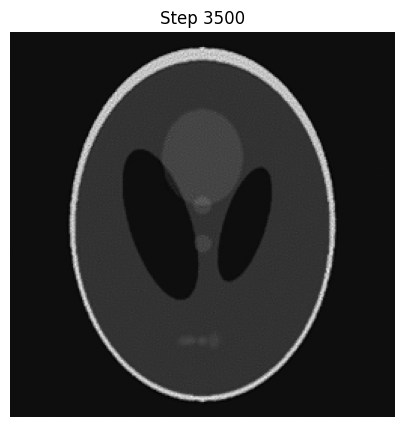

Step  3510, Loss: 7.0844e-03
Step  3520, Loss: 7.0329e-03
Step  3530, Loss: 6.7603e-03
Step  3540, Loss: 8.3111e-03
Step  3550, Loss: 6.4725e-03
Step  3560, Loss: 6.9339e-03
Step  3570, Loss: 6.5769e-03
Step  3580, Loss: 7.7054e-03
Step  3590, Loss: 6.0531e-03
Step  3600, Loss: 6.8449e-03
Step  3610, Loss: 5.9581e-03
Step  3620, Loss: 6.2990e-03
Step  3630, Loss: 6.1272e-03
Step  3640, Loss: 1.0724e-02
Step  3650, Loss: 6.7640e-03
Step  3660, Loss: 7.7395e-03
Step  3670, Loss: 7.8128e-03
Step  3680, Loss: 5.2236e-03
Step  3690, Loss: 7.8003e-03
Step  3700, Loss: 7.9953e-03
Step  3710, Loss: 8.1242e-03
Step  3720, Loss: 5.1709e-03
Step  3730, Loss: 5.2700e-03
Step  3740, Loss: 6.2907e-03
Step  3750, Loss: 6.4692e-03


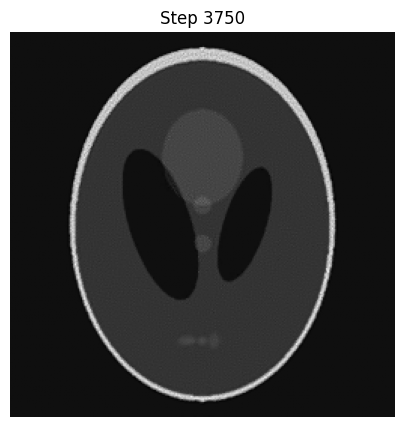

Step  3760, Loss: 6.0649e-03
Step  3770, Loss: 5.4339e-03
Step  3780, Loss: 6.4776e-03
Step  3790, Loss: 7.1153e-03
Step  3800, Loss: 5.8881e-03
Step  3810, Loss: 6.4353e-03
Step  3820, Loss: 6.6609e-03
Step  3830, Loss: 6.1924e-03
Step  3840, Loss: 5.6235e-03
Step  3850, Loss: 6.7228e-03
Step  3860, Loss: 6.5597e-03
Step  3870, Loss: 6.1885e-03
Step  3880, Loss: 7.5395e-03
Step  3890, Loss: 7.0944e-03
Step  3900, Loss: 4.7140e-03
Step  3910, Loss: 5.4212e-03
Step  3920, Loss: 5.6458e-03
Step  3930, Loss: 5.2751e-03
Step  3940, Loss: 6.2544e-03
Step  3950, Loss: 6.5947e-03
Step  3960, Loss: 5.7317e-03
Step  3970, Loss: 5.7047e-03
Step  3980, Loss: 5.2969e-03
Step  3990, Loss: 5.9899e-03
Step  4000, Loss: 5.2077e-03


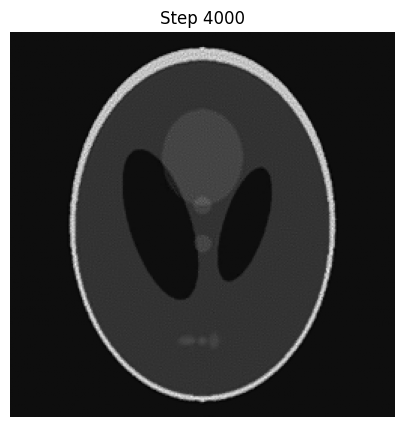

Step  4010, Loss: 6.5884e-03
Step  4020, Loss: 5.9250e-03
Step  4030, Loss: 6.9921e-03
Step  4040, Loss: 5.9216e-03
Step  4050, Loss: 4.8624e-03
Step  4060, Loss: 6.3493e-03
Step  4070, Loss: 5.4453e-03
Step  4080, Loss: 5.4416e-03
Step  4090, Loss: 6.6875e-03
Step  4100, Loss: 6.5479e-03
Step  4110, Loss: 4.8866e-03
Step  4120, Loss: 5.7424e-03
Step  4130, Loss: 5.5878e-03
Step  4140, Loss: 6.7667e-03
Step  4150, Loss: 5.4095e-03
Step  4160, Loss: 6.1279e-03
Step  4170, Loss: 4.4392e-03
Step  4180, Loss: 5.2552e-03
Step  4190, Loss: 5.9215e-03
Step  4200, Loss: 5.3645e-03
Step  4210, Loss: 4.9139e-03
Step  4220, Loss: 6.0189e-03
Step  4230, Loss: 5.1658e-03
Step  4240, Loss: 4.5010e-03
Step  4250, Loss: 5.8272e-03


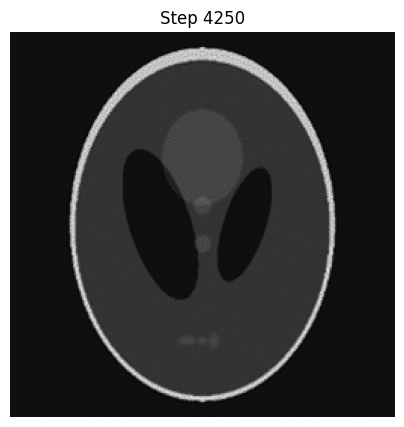

Step  4260, Loss: 5.4584e-03
Step  4270, Loss: 5.3610e-03
Step  4280, Loss: 4.7883e-03
Step  4290, Loss: 6.0977e-03
Step  4300, Loss: 4.5423e-03
Step  4310, Loss: 6.4173e-03
Step  4320, Loss: 5.8706e-03
Step  4330, Loss: 7.0994e-03
Step  4340, Loss: 6.2577e-03
Step  4350, Loss: 8.4181e-03
Step  4360, Loss: 5.7085e-03
Step  4370, Loss: 5.0743e-03
Step  4380, Loss: 4.8338e-03
Step  4390, Loss: 5.3355e-03
Step  4400, Loss: 5.0296e-03
Step  4410, Loss: 8.6631e-03
Step  4420, Loss: 9.5595e-03
Step  4430, Loss: 5.8152e-03
Step  4440, Loss: 5.3589e-03
Step  4450, Loss: 6.1839e-03
Step  4460, Loss: 7.7388e-03
Step  4470, Loss: 1.8148e-01
Step  4480, Loss: 1.4607e-01
Step  4490, Loss: 5.8635e-02
Step  4500, Loss: 3.5879e-02


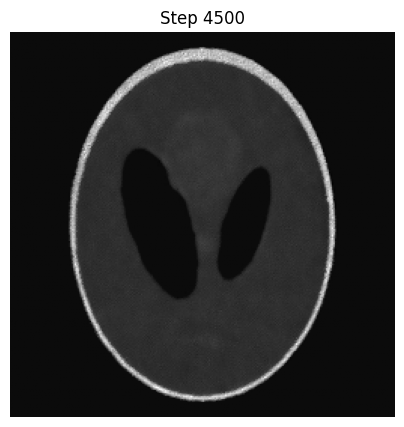

Step  4510, Loss: 2.2035e-02
Step  4520, Loss: 1.7268e-02
Step  4530, Loss: 1.5494e-02
Step  4540, Loss: 1.2941e-02
Step  4550, Loss: 1.0773e-02
Step  4560, Loss: 1.1875e-02
Step  4570, Loss: 9.6498e-03
Step  4580, Loss: 9.2909e-03
Step  4590, Loss: 9.6092e-03
Step  4600, Loss: 9.3973e-03
Step  4610, Loss: 9.8765e-03
Step  4620, Loss: 9.6685e-03
Step  4630, Loss: 9.2704e-03
Step  4640, Loss: 8.3079e-03
Step  4650, Loss: 8.4202e-03
Step  4660, Loss: 8.0348e-03
Step  4670, Loss: 8.1511e-03
Step  4680, Loss: 8.1466e-03
Step  4690, Loss: 7.1990e-03
Step  4700, Loss: 7.7022e-03
Step  4710, Loss: 7.9000e-03
Step  4720, Loss: 7.0232e-03
Step  4730, Loss: 6.5468e-03
Step  4740, Loss: 6.5049e-03
Step  4750, Loss: 7.5648e-03


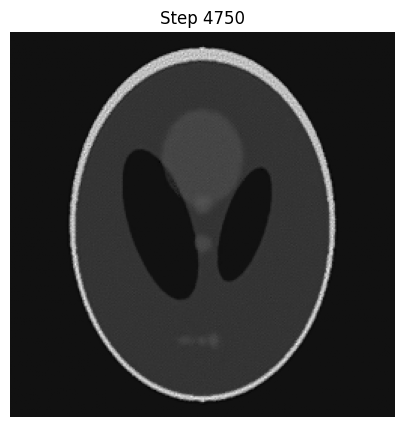

Step  4760, Loss: 7.7824e-03
Step  4770, Loss: 6.5600e-03
Step  4780, Loss: 7.0569e-03
Step  4790, Loss: 6.0693e-03
Step  4800, Loss: 6.6675e-03
Step  4810, Loss: 7.6941e-03
Step  4820, Loss: 6.7855e-03
Step  4830, Loss: 6.2969e-03
Step  4840, Loss: 6.2749e-03
Step  4850, Loss: 5.8473e-03
Step  4860, Loss: 6.5702e-03
Step  4870, Loss: 6.2261e-03
Step  4880, Loss: 7.1662e-03
Step  4890, Loss: 6.6165e-03
Step  4900, Loss: 6.1999e-03
Step  4910, Loss: 5.9431e-03
Step  4920, Loss: 6.1765e-03
Step  4930, Loss: 6.7285e-03
Step  4940, Loss: 5.9896e-03
Step  4950, Loss: 6.4409e-03
Step  4960, Loss: 6.0014e-03
Step  4970, Loss: 6.5977e-03
Step  4980, Loss: 5.5108e-03
Step  4990, Loss: 5.1142e-03
Step  5000, Loss: 5.6692e-03


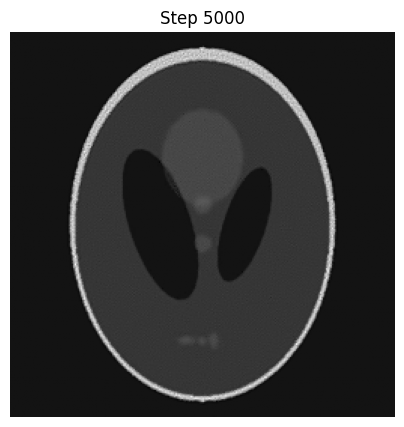

Step  5010, Loss: 6.2265e-03
Step  5020, Loss: 6.5951e-03
Step  5030, Loss: 5.9789e-03
Step  5040, Loss: 5.2821e-03
Step  5050, Loss: 5.6647e-03
Step  5060, Loss: 6.5923e-03
Step  5070, Loss: 5.9441e-03
Step  5080, Loss: 5.7709e-03
Step  5090, Loss: 5.8221e-03
Step  5100, Loss: 6.0958e-03
Step  5110, Loss: 5.8767e-03
Step  5120, Loss: 5.0550e-03
Step  5130, Loss: 6.0579e-03
Step  5140, Loss: 5.5103e-03
Step  5150, Loss: 5.4788e-03
Step  5160, Loss: 5.1471e-03
Step  5170, Loss: 5.5927e-03
Step  5180, Loss: 4.9658e-03
Step  5190, Loss: 5.5723e-03
Step  5200, Loss: 5.7500e-03
Step  5210, Loss: 4.4858e-03
Step  5220, Loss: 5.0898e-03
Step  5230, Loss: 4.4180e-03
Step  5240, Loss: 4.2002e-03
Step  5250, Loss: 6.3437e-03


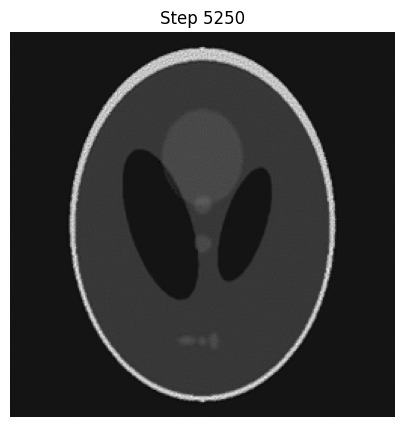

Step  5260, Loss: 5.5320e-03
Step  5270, Loss: 5.3795e-03
Step  5280, Loss: 4.8398e-03
Step  5290, Loss: 5.6355e-03
Step  5300, Loss: 5.1001e-03
Step  5310, Loss: 5.3796e-03
Step  5320, Loss: 4.5796e-03
Step  5330, Loss: 4.4109e-03
Step  5340, Loss: 5.0284e-03
Step  5350, Loss: 4.0653e-03
Step  5360, Loss: 5.4499e-03
Step  5370, Loss: 5.9958e-03
Step  5380, Loss: 5.2376e-03
Step  5390, Loss: 4.0926e-03
Step  5400, Loss: 5.2512e-03
Step  5410, Loss: 4.9905e-03
Step  5420, Loss: 7.0392e-03
Step  5430, Loss: 7.6115e-03
Step  5440, Loss: 5.2957e-03
Step  5450, Loss: 7.7241e-03
Step  5460, Loss: 6.9857e-03
Step  5470, Loss: 8.0416e-03
Step  5480, Loss: 5.2798e-03
Step  5490, Loss: 6.1838e-03
Step  5500, Loss: 4.6495e-03


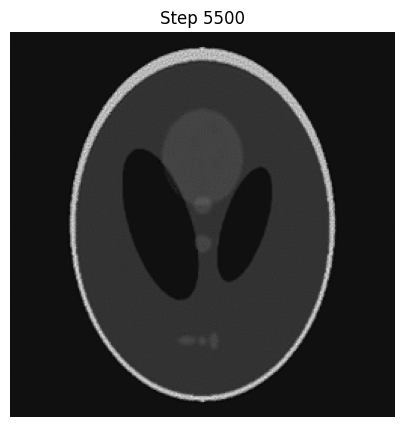

Step  5510, Loss: 9.7883e-03
Step  5520, Loss: 6.0170e-03
Step  5530, Loss: 6.5418e-03
Step  5540, Loss: 6.8224e-03
Step  5550, Loss: 7.4760e-03
Step  5560, Loss: 8.5448e-03
Step  5570, Loss: 7.6775e-03
Step  5580, Loss: 9.3903e-03
Step  5590, Loss: 9.8393e-03
Step  5600, Loss: 7.4576e-03
Step  5610, Loss: 8.8376e-03
Step  5620, Loss: 6.8014e-03
Step  5630, Loss: 7.5572e-03
Step  5640, Loss: 6.6842e-03
Step  5650, Loss: 6.9085e-03
Step  5660, Loss: 6.5229e-03
Step  5670, Loss: 6.4702e-03
Step  5680, Loss: 6.8504e-03
Step  5690, Loss: 7.4729e-03
Step  5700, Loss: 7.1428e-03
Step  5710, Loss: 4.7171e-03
Step  5720, Loss: 5.1061e-03
Step  5730, Loss: 5.6647e-03
Step  5740, Loss: 5.4100e-03
Step  5750, Loss: 4.8120e-03


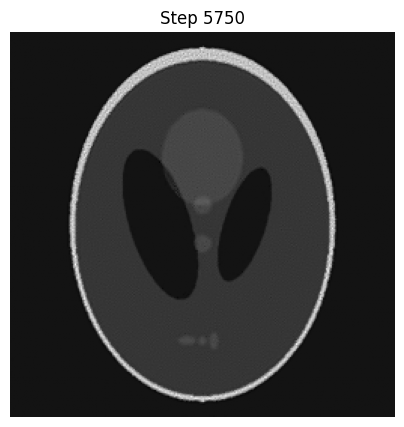

Step  5760, Loss: 5.3771e-03
Step  5770, Loss: 4.8541e-03
Step  5780, Loss: 4.9176e-03
Step  5790, Loss: 4.2064e-03
Step  5800, Loss: 5.4576e-03
Step  5810, Loss: 6.2020e-03
Step  5820, Loss: 1.0262e-02
Step  5830, Loss: 9.8971e-03
Step  5840, Loss: 1.0661e-02
Step  5850, Loss: 8.2700e-03
Step  5860, Loss: 8.1681e-03
Step  5870, Loss: 6.1103e-03
Step  5880, Loss: 7.4763e-03
Step  5890, Loss: 6.8334e-03
Step  5900, Loss: 8.1180e-03
Step  5910, Loss: 6.3664e-03
Step  5920, Loss: 7.5985e-03
Step  5930, Loss: 6.4496e-03
Step  5940, Loss: 7.3561e-03
Step  5950, Loss: 6.0171e-03
Step  5960, Loss: 6.7662e-03
Step  5970, Loss: 5.9562e-03
Step  5980, Loss: 6.1207e-03
Step  5990, Loss: 5.8709e-03
Step  6000, Loss: 6.0168e-03


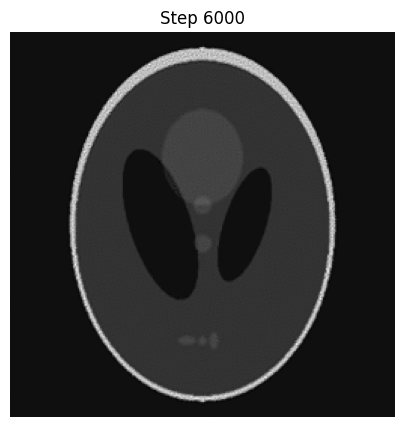

Step  6010, Loss: 6.5552e-03
Step  6020, Loss: 5.7611e-03
Step  6030, Loss: 5.8609e-03
Step  6040, Loss: 5.3627e-03
Step  6050, Loss: 5.3824e-03
Step  6060, Loss: 4.7572e-03
Step  6070, Loss: 3.6789e-03
Step  6080, Loss: 4.3885e-03
Step  6090, Loss: 3.4583e-03
Step  6100, Loss: 3.5313e-03
Step  6110, Loss: 4.0816e-03
Step  6120, Loss: 4.1705e-03
Step  6130, Loss: 4.5790e-03
Step  6140, Loss: 6.7909e-03
Step  6150, Loss: 4.8869e-03
Step  6160, Loss: 4.5129e-03
Step  6170, Loss: 5.8900e-03
Step  6180, Loss: 6.5947e-03
Step  6190, Loss: 4.0683e-03
Step  6200, Loss: 5.6496e-03
Step  6210, Loss: 4.3859e-03
Step  6220, Loss: 4.9451e-03
Step  6230, Loss: 5.4925e-03
Step  6240, Loss: 3.7653e-03
Step  6250, Loss: 4.7957e-03


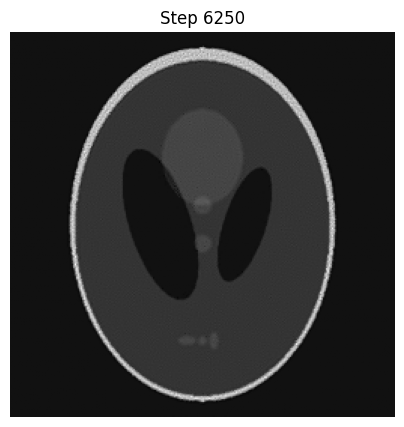

Step  6260, Loss: 3.7756e-03
Step  6270, Loss: 7.5456e-03
Step  6280, Loss: 5.7654e-03
Step  6290, Loss: 7.3011e-03
Step  6300, Loss: 6.6657e-03
Step  6310, Loss: 7.3071e-03
Step  6320, Loss: 5.2295e-03
Step  6330, Loss: 6.4487e-03
Step  6340, Loss: 6.2319e-03
Step  6350, Loss: 6.9166e-03
Step  6360, Loss: 4.8164e-03
Step  6370, Loss: 5.4719e-03
Step  6380, Loss: 5.5377e-03
Step  6390, Loss: 6.2035e-03
Step  6400, Loss: 5.7503e-03
Step  6410, Loss: 6.3203e-03
Step  6420, Loss: 5.2536e-03
Step  6430, Loss: 5.7195e-03
Step  6440, Loss: 5.1271e-03
Step  6450, Loss: 5.4272e-03
Step  6460, Loss: 5.4610e-03
Step  6470, Loss: 5.0049e-03
Step  6480, Loss: 5.8916e-03
Step  6490, Loss: 4.9242e-03
Step  6500, Loss: 4.3460e-03


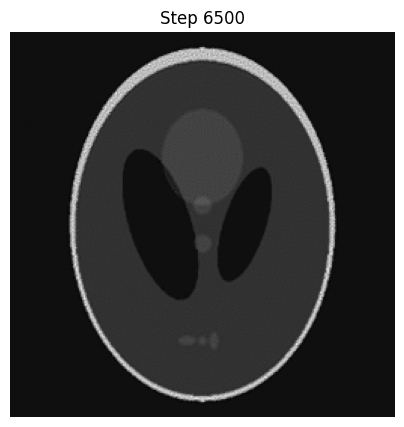

Step  6510, Loss: 4.1412e-03
Step  6520, Loss: 3.8206e-03
Step  6530, Loss: 3.1320e-03
Step  6540, Loss: 3.3500e-03
Step  6550, Loss: 3.0544e-03
Step  6560, Loss: 3.4415e-03
Step  6570, Loss: 4.1104e-03
Step  6580, Loss: 3.7788e-03
Step  6590, Loss: 4.1724e-03
Step  6600, Loss: 5.4825e-03
Step  6610, Loss: 3.2485e-03
Step  6620, Loss: 4.2761e-03
Step  6630, Loss: 4.0076e-03
Step  6640, Loss: 3.7020e-03
Step  6650, Loss: 4.1616e-03
Step  6660, Loss: 5.0146e-03
Step  6670, Loss: 4.3044e-03
Step  6680, Loss: 5.7610e-03
Step  6690, Loss: 3.8846e-03
Step  6700, Loss: 4.1707e-03
Step  6710, Loss: 5.0758e-03
Step  6720, Loss: 5.6085e-03
Step  6730, Loss: 5.1092e-03
Step  6740, Loss: 7.1550e-03
Step  6750, Loss: 5.3478e-03


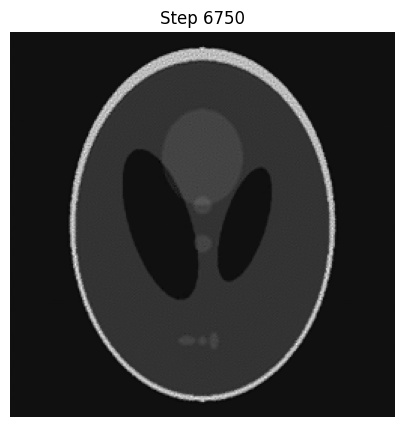

Step  6760, Loss: 4.9544e-03
Step  6770, Loss: 5.1794e-03
Step  6780, Loss: 5.9064e-03
Step  6790, Loss: 4.2523e-03
Step  6800, Loss: 5.6415e-03
Step  6810, Loss: 4.3863e-03
Step  6820, Loss: 5.8374e-03
Step  6830, Loss: 4.4592e-03
Step  6840, Loss: 5.3833e-03
Step  6850, Loss: 4.4005e-03
Step  6860, Loss: 5.0253e-03
Step  6870, Loss: 4.4403e-03
Step  6880, Loss: 4.2736e-03
Step  6890, Loss: 4.4314e-03
Step  6900, Loss: 4.7928e-03
Step  6910, Loss: 4.0647e-03
Step  6920, Loss: 4.3641e-03
Step  6930, Loss: 4.0892e-03
Step  6940, Loss: 4.2544e-03
Step  6950, Loss: 3.8589e-03
Step  6960, Loss: 3.9356e-03
Step  6970, Loss: 3.8858e-03
Step  6980, Loss: 3.9928e-03
Step  6990, Loss: 3.7251e-03
Step  7000, Loss: 3.4700e-03


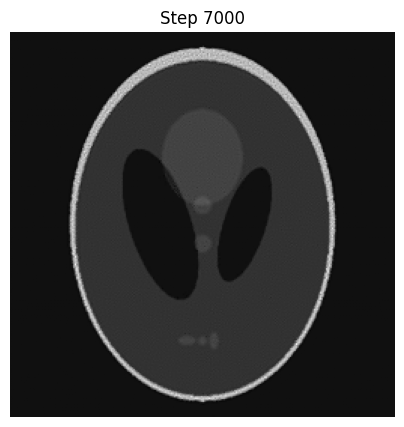

Step  7010, Loss: 3.7712e-03
Step  7020, Loss: 3.3635e-03
Step  7030, Loss: 3.1595e-03
Step  7040, Loss: 3.9960e-03
Step  7050, Loss: 3.0859e-03
Step  7060, Loss: 4.6276e-03
Step  7070, Loss: 4.0294e-03
Step  7080, Loss: 3.2300e-03
Step  7090, Loss: 4.2574e-03
Step  7100, Loss: 5.9650e-03
Step  7110, Loss: 5.6188e-03
Step  7120, Loss: 5.4107e-03
Step  7130, Loss: 5.4271e-03
Step  7140, Loss: 4.6956e-03
Step  7150, Loss: 5.8060e-03
Step  7160, Loss: 3.8148e-03
Step  7170, Loss: 4.4317e-03
Step  7180, Loss: 4.3900e-03
Step  7190, Loss: 3.7237e-03
Step  7200, Loss: 3.9997e-03
Step  7210, Loss: 4.7489e-03
Step  7220, Loss: 4.2058e-03
Step  7230, Loss: 3.7486e-03
Step  7240, Loss: 4.3161e-03
Step  7250, Loss: 4.3046e-03


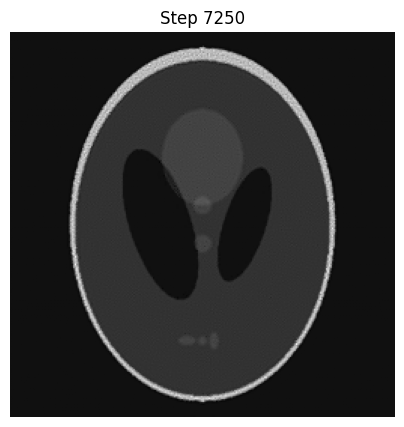

Step  7260, Loss: 3.4353e-03
Step  7270, Loss: 3.2458e-03
Step  7280, Loss: 5.3854e-03
Step  7290, Loss: 4.1840e-03
Step  7300, Loss: 5.1934e-03
Step  7310, Loss: 4.2104e-03
Step  7320, Loss: 4.6976e-03
Step  7330, Loss: 4.2959e-03
Step  7340, Loss: 5.0125e-03
Step  7350, Loss: 3.8942e-03
Step  7360, Loss: 4.8793e-03
Step  7370, Loss: 3.7935e-03
Step  7380, Loss: 4.6731e-03
Step  7390, Loss: 3.9464e-03
Step  7400, Loss: 4.5943e-03
Step  7410, Loss: 3.8025e-03
Step  7420, Loss: 4.6865e-03
Step  7430, Loss: 3.8751e-03
Step  7440, Loss: 4.4068e-03
Step  7450, Loss: 3.8825e-03
Step  7460, Loss: 4.1641e-03
Step  7470, Loss: 3.7242e-03
Step  7480, Loss: 3.9870e-03
Step  7490, Loss: 3.4997e-03
Step  7500, Loss: 3.7062e-03


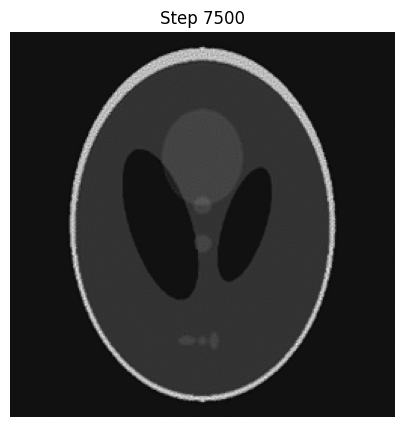

Step  7510, Loss: 3.7681e-03
Step  7520, Loss: 4.1236e-03
Step  7530, Loss: 3.9488e-03
Step  7540, Loss: 3.7925e-03
Step  7550, Loss: 3.5776e-03
Step  7560, Loss: 3.5441e-03
Step  7570, Loss: 3.2618e-03
Step  7580, Loss: 4.0457e-03
Step  7590, Loss: 3.2909e-03
Step  7600, Loss: 4.1774e-03
Step  7610, Loss: 4.0244e-03
Step  7620, Loss: 3.9819e-03
Step  7630, Loss: 2.8917e-03
Step  7640, Loss: 3.5647e-03
Step  7650, Loss: 3.6038e-03
Step  7660, Loss: 2.5656e-03
Step  7670, Loss: 2.3685e-03
Step  7680, Loss: 2.5706e-03
Step  7690, Loss: 3.1898e-03
Step  7700, Loss: 2.5192e-03
Step  7710, Loss: 2.7856e-03
Step  7720, Loss: 4.1115e-03
Step  7730, Loss: 4.2449e-03
Step  7740, Loss: 3.4128e-03
Step  7750, Loss: 2.9179e-03


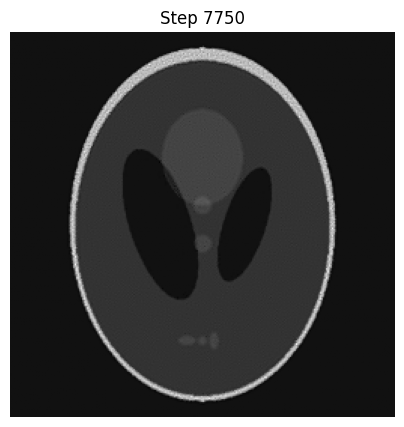

Step  7760, Loss: 3.0401e-03
Step  7770, Loss: 3.6108e-03
Step  7780, Loss: 3.4405e-03
Step  7790, Loss: 2.6617e-03
Step  7800, Loss: 4.1527e-03
Step  7810, Loss: 4.0969e-03
Step  7820, Loss: 3.9042e-03
Step  7830, Loss: 5.0103e-03
Step  7840, Loss: 4.2946e-03
Step  7850, Loss: 4.2134e-03
Step  7860, Loss: 4.6598e-03
Step  7870, Loss: 4.0312e-03
Step  7880, Loss: 4.9041e-03
Step  7890, Loss: 3.7788e-03
Step  7900, Loss: 4.7324e-03
Step  7910, Loss: 3.6321e-03
Step  7920, Loss: 4.5104e-03
Step  7930, Loss: 3.7505e-03
Step  7940, Loss: 4.0849e-03
Step  7950, Loss: 3.8631e-03
Step  7960, Loss: 4.2264e-03
Step  7970, Loss: 3.8606e-03
Step  7980, Loss: 4.5931e-03
Step  7990, Loss: 3.5068e-03
Step  8000, Loss: 4.2511e-03


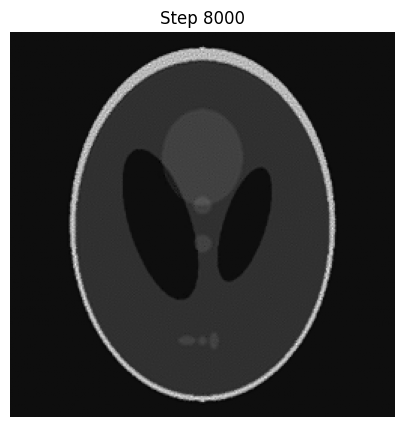

Step  8010, Loss: 3.5925e-03
Step  8020, Loss: 4.2448e-03
Step  8030, Loss: 3.5361e-03
Step  8040, Loss: 3.9534e-03
Step  8050, Loss: 3.6489e-03
Step  8060, Loss: 3.6376e-03
Step  8070, Loss: 3.2669e-03
Step  8080, Loss: 3.1426e-03
Step  8090, Loss: 3.4691e-03
Step  8100, Loss: 3.4787e-03
Step  8110, Loss: 3.0769e-03
Step  8120, Loss: 2.9501e-03
Step  8130, Loss: 2.6689e-03
Step  8140, Loss: 2.6427e-03
Step  8150, Loss: 2.7096e-03
Step  8160, Loss: 2.4362e-03
Step  8170, Loss: 2.1284e-03
Step  8180, Loss: 2.1356e-03
Step  8190, Loss: 2.0439e-03
Step  8200, Loss: 2.3900e-03
Step  8210, Loss: 2.5443e-03
Step  8220, Loss: 2.0871e-03
Step  8230, Loss: 2.2173e-03
Step  8240, Loss: 2.9734e-03
Step  8250, Loss: 4.2350e-03


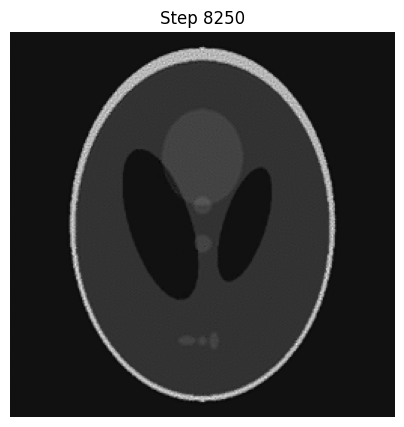

Step  8260, Loss: 3.5909e-03
Step  8270, Loss: 3.4818e-03
Step  8280, Loss: 4.6727e-03
Step  8290, Loss: 4.1316e-03
Step  8300, Loss: 4.0484e-03
Step  8310, Loss: 3.6826e-03
Step  8320, Loss: 3.8047e-03
Step  8330, Loss: 3.6783e-03
Step  8340, Loss: 4.3031e-03
Step  8350, Loss: 3.7984e-03
Step  8360, Loss: 4.5003e-03
Step  8370, Loss: 3.4814e-03
Step  8380, Loss: 4.3082e-03
Step  8390, Loss: 3.6055e-03
Step  8400, Loss: 4.2908e-03
Step  8410, Loss: 3.4804e-03
Step  8420, Loss: 4.1839e-03
Step  8430, Loss: 3.4348e-03
Step  8440, Loss: 4.2314e-03
Step  8450, Loss: 3.3846e-03
Step  8460, Loss: 4.1473e-03
Step  8470, Loss: 3.4308e-03
Step  8480, Loss: 4.1848e-03
Step  8490, Loss: 3.5268e-03
Step  8500, Loss: 3.9606e-03


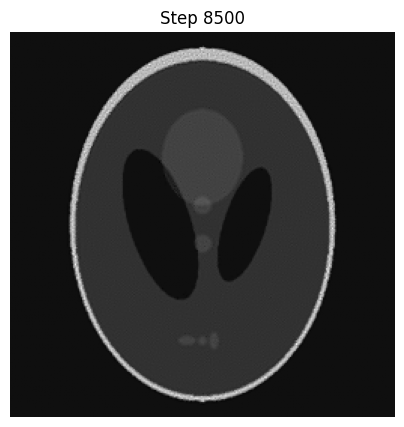

Step  8510, Loss: 3.4510e-03
Step  8520, Loss: 3.5650e-03
Step  8530, Loss: 3.3383e-03
Step  8540, Loss: 3.4487e-03
Step  8550, Loss: 3.2260e-03
Step  8560, Loss: 3.6004e-03
Step  8570, Loss: 3.4495e-03
Step  8580, Loss: 3.3321e-03
Step  8590, Loss: 3.1988e-03
Step  8600, Loss: 2.9667e-03
Step  8610, Loss: 3.1902e-03
Step  8620, Loss: 2.8806e-03
Step  8630, Loss: 3.0877e-03
Step  8640, Loss: 2.1656e-03
Step  8650, Loss: 2.3408e-03
Step  8660, Loss: 2.1775e-03
Step  8670, Loss: 2.4803e-03
Step  8680, Loss: 2.3170e-03
Step  8690, Loss: 2.2966e-03
Step  8700, Loss: 2.2375e-03
Step  8710, Loss: 2.4677e-03
Step  8720, Loss: 4.1830e-03
Step  8730, Loss: 4.1237e-03
Step  8740, Loss: 3.7255e-03
Step  8750, Loss: 3.9048e-03


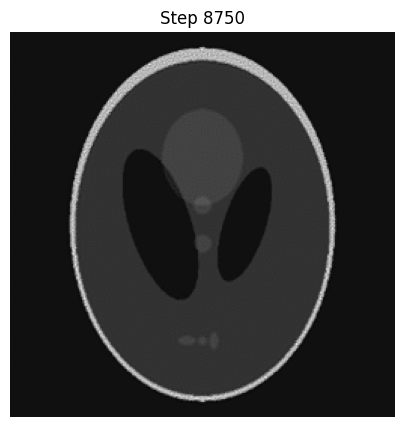

Step  8760, Loss: 4.9861e-03
Step  8770, Loss: 4.2512e-03
Step  8780, Loss: 4.3357e-03
Step  8790, Loss: 4.0652e-03
Step  8800, Loss: 4.3374e-03
Step  8810, Loss: 4.1144e-03
Step  8820, Loss: 3.7169e-03
Step  8830, Loss: 4.6136e-03
Step  8840, Loss: 3.8970e-03
Step  8850, Loss: 4.4650e-03
Step  8860, Loss: 3.6139e-03
Step  8870, Loss: 4.4419e-03
Step  8880, Loss: 3.7726e-03
Step  8890, Loss: 4.2514e-03
Step  8900, Loss: 3.6926e-03
Step  8910, Loss: 3.9714e-03
Step  8920, Loss: 3.5011e-03
Step  8930, Loss: 3.7046e-03
Step  8940, Loss: 3.6019e-03
Step  8950, Loss: 3.6651e-03
Step  8960, Loss: 4.0490e-03
Step  8970, Loss: 2.9509e-03
Step  8980, Loss: 2.5546e-03
Step  8990, Loss: 2.4432e-03
Step  9000, Loss: 2.5674e-03


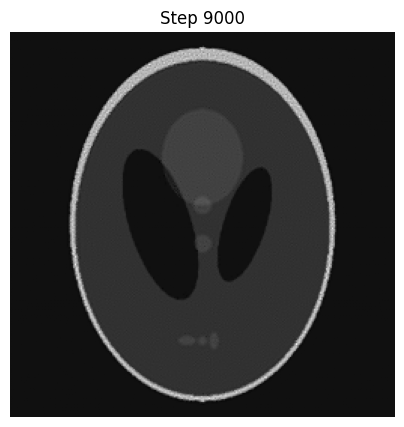

Step  9010, Loss: 2.2998e-03
Step  9020, Loss: 2.1662e-03
Step  9030, Loss: 2.3869e-03
Step  9040, Loss: 2.4995e-03
Step  9050, Loss: 2.4311e-03
Step  9060, Loss: 2.2565e-03
Step  9070, Loss: 2.7851e-03
Step  9080, Loss: 2.7867e-03
Step  9090, Loss: 2.2958e-03
Step  9100, Loss: 2.3718e-03
Step  9110, Loss: 2.2218e-03
Step  9120, Loss: 2.2464e-03
Step  9130, Loss: 2.4284e-03
Step  9140, Loss: 3.0615e-03
Step  9150, Loss: 3.2129e-03
Step  9160, Loss: 2.9202e-03
Step  9170, Loss: 3.1805e-03
Step  9180, Loss: 2.4317e-03
Step  9190, Loss: 3.1824e-03
Step  9200, Loss: 2.5501e-03
Step  9210, Loss: 2.6350e-03
Step  9220, Loss: 2.7694e-03
Step  9230, Loss: 3.2766e-03
Step  9240, Loss: 3.7311e-03
Step  9250, Loss: 3.3297e-03


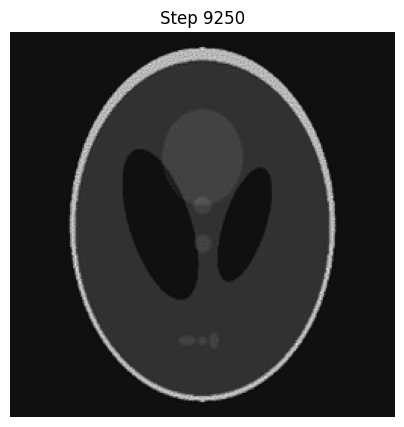

Step  9260, Loss: 2.7368e-03
Step  9270, Loss: 4.9140e-03
Step  9280, Loss: 4.6995e-03
Step  9290, Loss: 4.3348e-03
Step  9300, Loss: 4.6033e-03
Step  9310, Loss: 3.7191e-03
Step  9320, Loss: 4.5224e-03
Step  9330, Loss: 3.7789e-03
Step  9340, Loss: 4.4956e-03
Step  9350, Loss: 3.5455e-03
Step  9360, Loss: 4.4554e-03
Step  9370, Loss: 3.4900e-03
Step  9380, Loss: 4.3601e-03
Step  9390, Loss: 3.5959e-03
Step  9400, Loss: 4.2647e-03
Step  9410, Loss: 4.2500e-03
Step  9420, Loss: 4.3007e-03
Step  9430, Loss: 3.6201e-03
Step  9440, Loss: 3.8464e-03
Step  9450, Loss: 3.4400e-03
Step  9460, Loss: 3.7387e-03
Step  9470, Loss: 3.6173e-03
Step  9480, Loss: 3.5731e-03
Step  9490, Loss: 3.3599e-03
Step  9500, Loss: 3.3302e-03


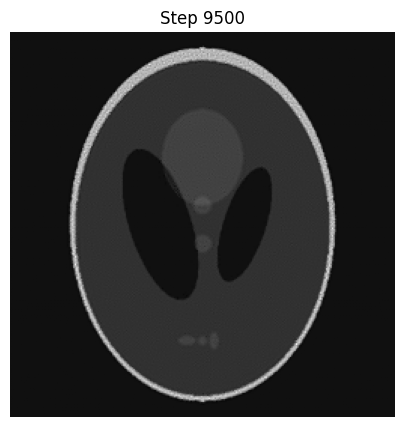

Step  9510, Loss: 2.9175e-03
Step  9520, Loss: 3.5265e-03
Step  9530, Loss: 2.7347e-03
Step  9540, Loss: 3.0323e-03
Step  9550, Loss: 3.4702e-03
Step  9560, Loss: 2.8568e-03
Step  9570, Loss: 2.8497e-03
Step  9580, Loss: 2.7937e-03
Step  9590, Loss: 2.4871e-03
Step  9600, Loss: 2.5682e-03
Step  9610, Loss: 2.4970e-03
Step  9620, Loss: 3.0240e-03
Step  9630, Loss: 2.6615e-03
Step  9640, Loss: 2.7302e-03
Step  9650, Loss: 2.9895e-03
Step  9660, Loss: 3.3796e-03
Step  9670, Loss: 2.2287e-03
Step  9680, Loss: 4.3254e-03
Step  9690, Loss: 3.4059e-03
Step  9700, Loss: 3.7039e-03
Step  9710, Loss: 2.9619e-03
Step  9720, Loss: 3.5146e-03
Step  9730, Loss: 3.7571e-03
Step  9740, Loss: 2.6543e-03
Step  9750, Loss: 3.4778e-03


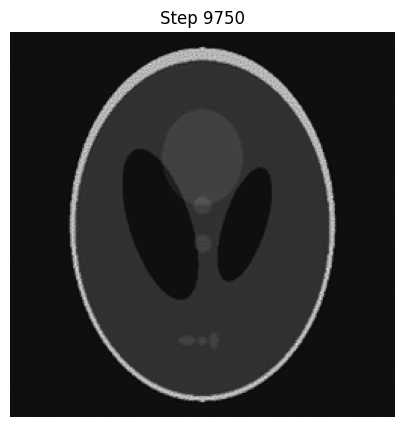

Step  9760, Loss: 4.8359e-03
Step  9770, Loss: 4.3958e-03
Step  9780, Loss: 3.2468e-03
Step  9790, Loss: 3.5642e-03
Step  9800, Loss: 3.4879e-03
Step  9810, Loss: 2.7674e-03
Step  9820, Loss: 2.9087e-03
Step  9830, Loss: 2.8040e-03
Step  9840, Loss: 3.1882e-03
Step  9850, Loss: 3.1515e-03
Step  9860, Loss: 2.8344e-03
Step  9870, Loss: 2.2383e-03
Step  9880, Loss: 2.0722e-03
Step  9890, Loss: 2.4783e-03
Step  9900, Loss: 2.0216e-03
Step  9910, Loss: 2.1088e-03
Step  9920, Loss: 2.0105e-03
Step  9930, Loss: 1.9610e-03
Step  9940, Loss: 1.9959e-03
Step  9950, Loss: 2.4008e-03
Step  9960, Loss: 2.0937e-03
Step  9970, Loss: 2.5413e-03
Step  9980, Loss: 2.8410e-03
Step  9990, Loss: 3.1644e-03


In [108]:
# ===============================================================
# 7. Training loop
# ===============================================================
n_steps = 10_000
losses = []


for step in range(n_steps):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    losses.append(loss)

    if step % 10 == 0:
        print(f"Step {step:5d}, Loss: {float(loss):.4e}")

    if step % 250 == 0:
        I_hr_pred = model(z_hr, training=False)[0, :, :, 0]
        plt.figure(figsize=(5,5))
        plt.imshow(I_hr_pred, cmap='gray')
        plt.title(f"Step {step}")
        plt.axis('off')
        plt.show()


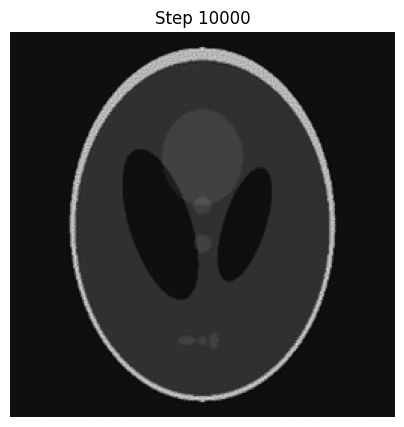

In [111]:
I_hr_pred = model(z_hr, training=False)[0, :, :, 0]
plt.figure(figsize=(5,5))
plt.imshow(I_hr_pred, cmap='gray')
plt.title(f"Step {step+1}")
plt.axis('off')
plt.show()